In [1]:

from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
from sklearn.model_selection import train_test_split
import numpy as np
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt


Mounted at /content/drive


In [3]:
# Define source directory from Google Drive
src_dir = "/content/drive/MyDrive/breast_ultrasound_images"
base_dir = "/content/dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")


In [6]:
# Clean and prepare split folders
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Split data into train/val folders (excluding _mask.png files)
for category in os.listdir(src_dir):
    category_path = os.path.join(src_dir, category)
    all_images = sorted([img for img in os.listdir(category_path) if not img.endswith('_mask.png')])

    train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(val_dir, category), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(category_path, img), os.path.join(train_dir, category, img))
    for img in val_imgs:
        shutil.copy(os.path.join(category_path, img), os.path.join(val_dir, category, img))

In [7]:
import pandas as pd

train_list = []
val_list = []

for category in sorted(os.listdir(src_dir)):
    category_path = os.path.join(src_dir, category)
    all_images = sorted([img for img in os.listdir(category_path) if not img.endswith('_mask.png')])
    train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)
    train_list.extend([f"{category}/{img}" for img in sorted(train_imgs)])
    val_list.extend([f"{category}/{img}" for img in sorted(val_imgs)])

pd.DataFrame({'filename': train_list}).to_csv('train_files.csv', index=False)
pd.DataFrame({'filename': val_list}).to_csv('val_files.csv', index=False)
print(f"Train: {len(train_list)}, Val: {len(val_list)}")

Train: 637, Val: 161


In [8]:
train_count = sum(len(os.listdir(os.path.join(train_dir, c))) for c in os.listdir(train_dir))
val_count = sum(len(os.listdir(os.path.join(val_dir, c))) for c in os.listdir(val_dir))
print(f"Train: {train_count}, Val: {val_count}, Total: {train_count + val_count}")

Train: 637, Val: 161, Total: 798


In [9]:
import os

count = 0
for category in sorted(os.listdir(src_dir)):
    category_path = os.path.join(src_dir, category)
    all_files = sorted(os.listdir(category_path))
    masks = [f for f in all_files if 'mask' in f.lower()]
    images = [f for f in all_files if not f.endswith('_mask.png')]
    strict_images = [f for f in all_files if 'mask' not in f.lower()]
    print(f"{category}: {len(all_files)} total, {len(masks)} masks, {len(images)} current filter, {len(strict_images)} strict filter")
    count += len(strict_images)

print(f"\nStrict total: {count}")

benign: 891 total, 454 masks, 454 current filter, 437 strict filter
malignant: 421 total, 211 masks, 211 current filter, 210 strict filter
normal: 266 total, 133 masks, 133 current filter, 133 strict filter

Strict total: 780


In [10]:
import os

train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

for category in sorted(os.listdir(train_dir)):
    t = len(os.listdir(os.path.join(train_dir, category)))
    v = len(os.listdir(os.path.join(val_dir, category)))
    print(f"{category}: train={t}, val={v}, total={t+v}")

benign: train=363, val=91, total=454
malignant: train=168, val=43, total=211
normal: train=106, val=27, total=133


In [11]:
import pandas as pd

train_list = []
val_list = []

for category in sorted(os.listdir(src_dir)):
    category_path = os.path.join(src_dir, category)
    all_images = sorted([img for img in os.listdir(category_path) if not img.endswith('_mask.png')])
    train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)
    train_list.extend([f"{category}/{img}" for img in sorted(train_imgs)])
    val_list.extend([f"{category}/{img}" for img in sorted(val_imgs)])

pd.DataFrame({'filename': train_list}).to_csv('train_files.csv', index=False)
pd.DataFrame({'filename': val_list}).to_csv('val_files.csv', index=False)
print(f"Train: {len(train_list)}, Val: {len(val_list)}")

Train: 637, Val: 161


In [ ]:
# ------------------ IMAGE SIZE & DATA ------------------
img_size = 192
batch_size = 16

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

print("Class indices:", train_gen.class_indices)


Found 637 images belonging to 3 classes.
Found 161 images belonging to 3 classes.
Class indices: {'benign': 0, 'malignant': 1, 'normal': 2}


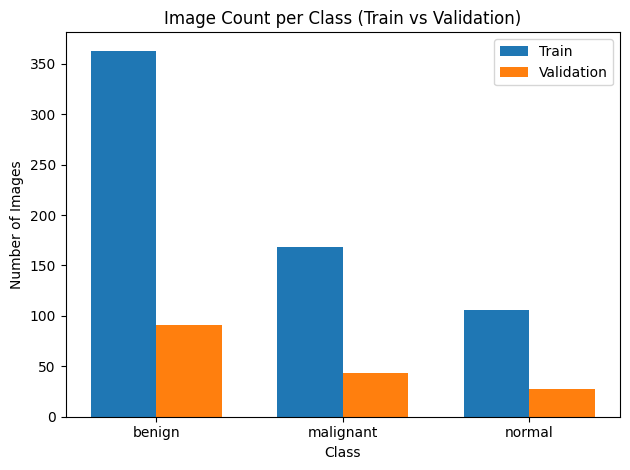

In [ ]:
import matplotlib.pyplot as plt
import os

# Count images per class in a directory
def count_images_per_class(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path) if not f.endswith('_mask.png')])
            class_counts[class_name] = count
    return class_counts

# Replace with your actual dataset paths
train_counts = count_images_per_class("/content/dataset/train")
val_counts = count_images_per_class("/content/dataset/val")

# Plot
classes = list(train_counts.keys())
x = range(len(classes))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x, [train_counts[c] for c in classes], width=width, label='Train')
ax.bar([i + width for i in x], [val_counts[c] for c in classes], width=width, label='Validation')

ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.set_title("Image Count per Class (Train vs Validation)")
ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(classes)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# CLEAN RUNTIME MODEL VALIDATION CHECK
# ============================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# 1️⃣ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2️⃣ Load saved model
model_path = '/content/drive/MyDrive/Model/breast_ultrasound_mobilenet.h5'
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

# 3️⃣ Validation directory (your split folder)
val_dir = '/content/dataset/val'   # <-- make sure this matches your split location

img_size = 192
batch_size = 16

# 4️⃣ Validation generator (NO shuffle)
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# 5️⃣ Evaluate
loss, acc = model.evaluate(val_gen)
print(f"\nValidation Accuracy: {acc*100:.2f}%")

# 6️⃣ Predictions
val_gen.reset()
pred_probs = model.predict(val_gen)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = val_gen.classes

# 7️⃣ Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
print("\nConfusion Matrix:\n", cm)

# 8️⃣ Manual accuracy verification
correct = np.trace(cm)
total = np.sum(cm)
print("\nManual Accuracy:", correct/total)

# 9️⃣ Classification Report
print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=val_gen.class_indices.keys()))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model loaded successfully
Found 161 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9098 - loss: 0.4400

Validation Accuracy: 88.20%
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 717ms/step

Confusion Matrix:
 [[83  3  5]
 [ 3 38  2]
 [ 5  1 21]]

Manual Accuracy: 0.8819875776397516

Classification Report:

              precision    recall  f1-score   support

      benign       0.91      0.91      0.91        91
   malignant       0.90      0.88      0.89        43
      normal       0.75      0.78      0.76        27

    accuracy                           0.88       161
   macro avg       0.86      0.86      0.86       161
weighted avg       0.88      0.88      0.88       161



In [ ]:
# ===========================================
# 5-FOLD STRATIFIED CROSS-VALIDATION (FINAL)
# ===========================================

import os
import random
import numpy as np
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ---------------------------
# Parameters
# ---------------------------
img_size = 192
batch_size = 16
num_classes = 3
epochs = 150

data_dir = "/content/drive/MyDrive/breast_ultrasound_images"

# ---------------------------
# Load all image paths + labels
# ---------------------------
image_paths = []
labels = []

class_names = sorted(os.listdir(data_dir))

for label_idx, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    for file in os.listdir(class_path):
        if not file.endswith("_mask.png"):
            image_paths.append(os.path.join(class_path, file))
            labels.append(label_idx)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))

# ---------------------------
# Stratified K-Fold Setup
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_accuracies = []
fold_f1_scores = []
fold_aucs = []

# ---------------------------
# Training Loop
# ---------------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(image_paths, labels)):

    print(f"\n========== Fold {fold+1} ==========")

    # Split
    X_train_paths = image_paths[train_idx]
    X_val_paths = image_paths[val_idx]
    y_train = labels[train_idx]
    y_val = labels[val_idx]

    # Load images
    def load_images(paths):
        imgs = []
        for p in paths:
            img = load_img(p, target_size=(img_size, img_size))
            img = img_to_array(img)
            imgs.append(img)
        return np.array(imgs)

    X_train = load_images(X_train_paths)
    X_val = load_images(X_val_paths)

    # Preprocess
    X_train = preprocess_input(X_train)
    X_val = preprocess_input(X_val)

    y_train_cat = to_categorical(y_train, num_classes)
    y_val_cat = to_categorical(y_val, num_classes)

    # ---------------------------
    # Build Model
    # ---------------------------
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=Input(shape=(img_size, img_size, 3))
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    # Fine-tune top 15 layers
    base_model.trainable = True
    for layer in base_model.layers[:-15]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=5e-5),
        loss=CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    # Train
    model.fit(
        X_train,
        y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    # Predict
    y_pred_probs = model.predict(X_val)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    auc = roc_auc_score(y_val_cat, y_pred_probs, multi_class="ovr", average="macro")

    fold_accuracies.append(acc)
    fold_f1_scores.append(f1)
    fold_aucs.append(auc)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    print(f"Fold {fold+1} Macro F1: {f1:.4f}")
    print(f"Fold {fold+1} Macro AUC: {auc:.4f}")

    # VERY IMPORTANT
    tf.keras.backend.clear_session()

# ---------------------------
# Final CV Results
# ---------------------------
print("\n========== FINAL 5-FOLD RESULTS ==========")

print("Mean Accuracy: {:.4f} ± {:.4f}".format(
    np.mean(fold_accuracies), np.std(fold_accuracies)))

print("Mean Macro F1: {:.4f} ± {:.4f}".format(
    np.mean(fold_f1_scores), np.std(fold_f1_scores)))

print("Mean Macro AUC: {:.4f} ± {:.4f}".format(
    np.mean(fold_aucs), np.std(fold_aucs)))


Total images: 798

========== Fold 1 ==========


/tmp/ipython-input-3910590421.py:104: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 310ms/step - accuracy: 0.4299 - loss: 1.1633 - val_accuracy: 0.2625 - val_loss: 2.1485
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7696 - loss: 0.6305 - val_accuracy: 0.2937 - val_loss: 2.1565
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8425 - loss: 0.5112 - val_accuracy: 0.3063 - val_loss: 2.0998
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9005 - loss: 0.4373 - val_accuracy: 0.3562 - val_loss: 1.9086
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9134 - loss: 0.3779 - val_accuracy: 0.4000 - val_loss: 1.8568
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9400 - loss: 0.3444 - val_accuracy: 0.4750 - val_loss: 1.6337
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9545 - loss: 0.3114 - val_accuracy: 0.5000 - val_loss: 1.4721
Epoch 8/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9645 - loss: 0.2929 - val_accuracy: 

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step
Fold 1 Accuracy: 0.8438
Fold 1 Macro F1: 0.8204
Fold 1 Macro AUC: 0.9458

========== Fold 2 ==========


/tmp/ipython-input-3910590421.py:104: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


...

Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 319ms/step - accuracy: 0.4886 - loss: 1.0884 - val_accuracy: 0.2937 - val_loss: 2.5863
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7749 - loss: 0.6486 - val_accuracy: 0.3500 - val_loss: 2.6067
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8631 - loss: 0.5163 - val_accuracy: 0.3938 - val_loss: 2.4608
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8611 - loss: 0.4628 - val_accuracy: 0.4313 - val_loss: 2.3319
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9086 - loss: 0.3887 - val_accuracy: 0.4750 - val_loss: 2.2580
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9255 - loss: 0.3591 - val_accuracy: 0.4750 - val_loss: 2.2614
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9256 - loss: 0.3447 - val_accuracy: 0.4625 - val_loss: 2.1769
Epoch 8/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9812 - loss: 0.2857 - val_accuracy: 

/tmp/ipython-input-3910590421.py:104: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 401ms/step - accuracy: 0.3821 - loss: 1.3028 - val_accuracy: 0.1635 - val_loss: 3.3648
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7125 - loss: 0.7151 - val_accuracy: 0.1824 - val_loss: 3.4009
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8546 - loss: 0.5153 - val_accuracy: 0.1887 - val_loss: 3.1405
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8729 - loss: 0.4700 - val_accuracy: 0.2579 - val_loss: 2.8197
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9089 - loss: 0.3930 - val_accuracy: 0.2956 - val_loss: 2.7032
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9139 - loss: 0.3766 - val_accuracy: 0.3270 - val_loss: 2.4652
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9535 - loss: 0.3338 - val_accuracy: 0.4025 - val_loss: 2.3427
Epoch 8/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9654 - loss: 0.3021 - val_accuracy: 

/tmp/ipython-input-3910590421.py:104: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 398ms/step - accuracy: 0.5932 - loss: 0.9796 - val_accuracy: 0.6038 - val_loss: 1.0275
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7927 - loss: 0.5894 - val_accuracy: 0.6038 - val_loss: 1.1122
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8386 - loss: 0.5076 - val_accuracy: 0.5849 - val_loss: 1.1919
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8905 - loss: 0.4406 - val_accuracy: 0.5912 - val_loss: 1.1146
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8985 - loss: 0.3944 - val_accuracy: 0.5660 - val_loss: 1.1916
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9244 - loss: 0.3509 - val_accuracy: 0.5786 - val_loss: 1.2343
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9690 - loss: 0.2950 - val_accuracy: 0.5660 - val_loss: 1.2856
Epoch 8/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9728 - loss: 0.2809 - val_accuracy: 